# Latent geometry across the predictive campaign

This is the geometry counterpart to `part_1`/`part_2` (reconstruction): where those ask
whether a difference reaches the decoded spectrum, this notebook asks what happens in
the encoder's own representation — variance, angular structure, cross-seed
reproducibility and sensitivity to input perturbation — for every ready model.

## Introduction

Most of what this notebook shows is already computed by the base full-campaign
inference cache (`predictive_precompute.precompute`, via `predictive_geometry.geometry_tables`/
`structure_summary`/`label_structure_correlation`) and is read directly from its
`geometry` table; cross-model reproducibility likewise reuses the already-existing
`predictive_reports.geometry_similarity`. Only two things needed a new, dedicated pass
over every model — encoder sensitivity to isotropic input perturbation, and the raw
angular-structure samples behind the base layer's summary statistics — computed once by
`predictive_precompute.latent_geometry` and read here like everything else.

### Assumptions

- **Structure statistics are computed on the canonicalized latent $u$**, never the raw
  post-LayerNorm code $z$: `structure_test`'s uniform-sphere null assumes the
  zero-row-sum/constant-norm constraint canonicalization enforces.
- **Cross-seed reproducibility pairs same-condition, different-seed models.**
  `geometry_similarity`'s `same_condition` and `same_seed` flags let this notebook
  select exactly that comparison (`same_condition & ~same_seed`) from a table that also
  contains every cross-condition pair; the two are not filtered apart at precompute
  time; this notebook does. Requires at least two ready repetitions of a condition —
  with an unfinished campaign some conditions may contribute nothing here.
- **`vpu_precision_sweep` is a single run, not a repeated condition.** It cannot appear in
  the reproducibility-across-seeds section for the same reason `part_1`/`part_2`
  exclude it there; it is still compared on every other section here.

### Notation

For model $m$, $u_m \in \mathbb{R}^{N\times D}$ is its canonicalized latent code over the
shared evaluation sample. $\mathrm{tr}(u_m)$, $\mathrm{rank}_{\mathrm{eff}}(u_m)$ and
$\mathrm{PR}(u_m)$ are its trace, effective rank and participation ratio. For an
isotropic input perturbation of size $\epsilon$, $\bar\theta_m(\epsilon)$ is the mean
angular displacement of $u_m$ in degrees.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_precompute as precompute
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_reports as reports
from msi_autoencoder_wrapper.utils.logger import get_custom_logger
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

logger = get_custom_logger("latent_geometry")

from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import (
    load_model_catalog, load_visualization_theme, select_catalog_frame,
)


2026-09-19 23:39:03,151 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-19 23:39:03,154 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-19 23:39:03,581 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-19 23:39:03,584 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 28 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-19 23:39:03,593 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-19 23:39:03,594 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 46 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-19 23:39:03,614 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-09-19 23:39:03,631 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-09-19 23:39:03,633 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 33 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Configuration

## Producing the tables this notebook reads

### Methodology

#### Implementation

Encoding the evaluation sample under an isotropic perturbation sweep, for every ready
model, is minutes of GPU work. That work lives in `predictive_precompute.latent_geometry`,
is configured by `analysis_settings.yaml` next to this notebook, and writes its tables to
this notebook's results directory. It requires the base inference cache
(`predictive_precompute.precompute`) to already be populated, since most of what this
notebook shows is read from that cache's own `geometry` table directly.

Run it once, detached, with the command printed below. It refuses to start on the
processor unless explicitly allowed. The command is generated by the runner itself, so
the instruction cannot drift from the entry point it describes.

### Remarks

### Notes

In [2]:
from msi_autoencoder_wrapper.analysis.precompute.cli import run_precompute_command
SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/19_09_26_metaspace_heads_vpu_jaccard/analysis_settings.yaml")
ANALYSIS = "latent_geometry"

settings = campaign.load_settings(SETTINGS_PATH)
settings["settings_path"] = str(SETTINGS_PATH)
analysis_settings = precompute.analysis_settings(settings, ANALYSIS)
ARTIFACT_DIR = analysis_settings["output_directory"]

theme = resolve_theme(None)
theme.apply()

# --- embedded figure resolution --------------------------------------------
FIGURE_RASTER_DPI = 100
plt.rcParams["savefig.dpi"] = FIGURE_RASTER_DPI
# ---------------------------------------------------------------------------

print("Run the precompute once, in the background:")
print(f"  {run_precompute_command(SETTINGS_PATH)}")
print("\nOr in the foreground, to watch it:")
print(f"  {run_precompute_command(SETTINGS_PATH, background=False)}")

Run the precompute once, in the background:
  nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings assets/experiments/autoencoder_architecture/notebooks/segmentation_model/19_09_26_metaspace_heads_vpu_jaccard/analysis_settings.yaml > assets/experiments/autoencoder_architecture/notebooks/segmentation_model/19_09_26_metaspace_heads_vpu_jaccard/shared_precompute.log 2>&1 &

Or in the foreground, to watch it:
  uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings assets/experiments/autoencoder_architecture/notebooks/segmentation_model/19_09_26_metaspace_heads_vpu_jaccard/analysis_settings.yaml


In [3]:
# Tables produced by the command above; `load_analysis_table` reports the command again
# if one is missing, so a fresh checkout fails with an instruction rather than a stack
# trace. `geometry` itself comes from the BASE cache (`predictive_precompute.load_table`),
# not from this analysis routine — it was already computed by the full-campaign pass.
all_models, _ = campaign.inventory(settings)
models = all_models.copy()
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import (
    load_model_catalog, load_visualization_theme, select_catalog_frame,
)
models = load_model_catalog(settings)
ready = models[models.ready]
geometry_frame = select_catalog_frame(precompute.load_table(settings, "geometry"), models)
sensitivity_frame = select_catalog_frame(precompute.load_analysis_table(settings, ANALYSIS, "angular_sensitivity"), models)
structure_frame = select_catalog_frame(precompute.load_analysis_table(settings, ANALYSIS, "angular_structure"), models)
cos_frame = select_catalog_frame(precompute.load_analysis_table(settings, ANALYSIS, "angular_structure_samples"), models)
similarity_frame = select_catalog_frame(reports.geometry_similarity(settings, all_models[all_models.ready]), models)

provenance = precompute.load_analysis_metadata(settings, ANALYSIS)
EVALUATION_SPLIT = provenance["evaluation_split"]

CONDITION_ORDER = reports.condition_order(ready)
LABEL_COLOR = {label: theme.color_for_model(label, index) for index, label in enumerate(CONDITION_ORDER)}

print(f"{ready.model_id.nunique()} ready model(s), {len(geometry_frame)} geometry row(s), "
     f"{len(similarity_frame)} pairwise similarity row(s)")
print(f"precomputed at commit {provenance['git_commit']} on {provenance['settings']['device']}")

2026-09-19 23:39:19,120 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_campaign:320 | Audited 170 model manifests across 2 sources.


80 ready model(s), 5120 geometry row(s), 37920 pairwise similarity row(s)
precomputed at commit b2026c4bcdb93b4bb5ceb647ae2bbdfb06d0feef on cuda


## Encoding every model: variance and dispersion statistics

### Methodology

#### Theoretical

The trace, effective rank and participation ratio of the canonicalized code's
covariance describe how the encoder uses its available latent dimensions: a collapsed
representation has low trace and low effective rank regardless of what the decoder
does with it. The 2-NN intrinsic dimension estimates the same thing from local
neighbourhood scaling rather than global covariance, so agreement between the two is a
check, not a redundancy.

#### Implementation

Every statistic here comes from the base inference cache's own `geometry` table
(`space == 'u'`, computed once per model over the evaluation split); nothing is
recomputed in this notebook.

#### Figure descriptions

One panel per statistic, x-axis the condition label (baseline first), y-axis its value
as a violin over ready models sharing that condition (repetitions), with individual
repetitions overlaid as points.

### Remarks

### Notes

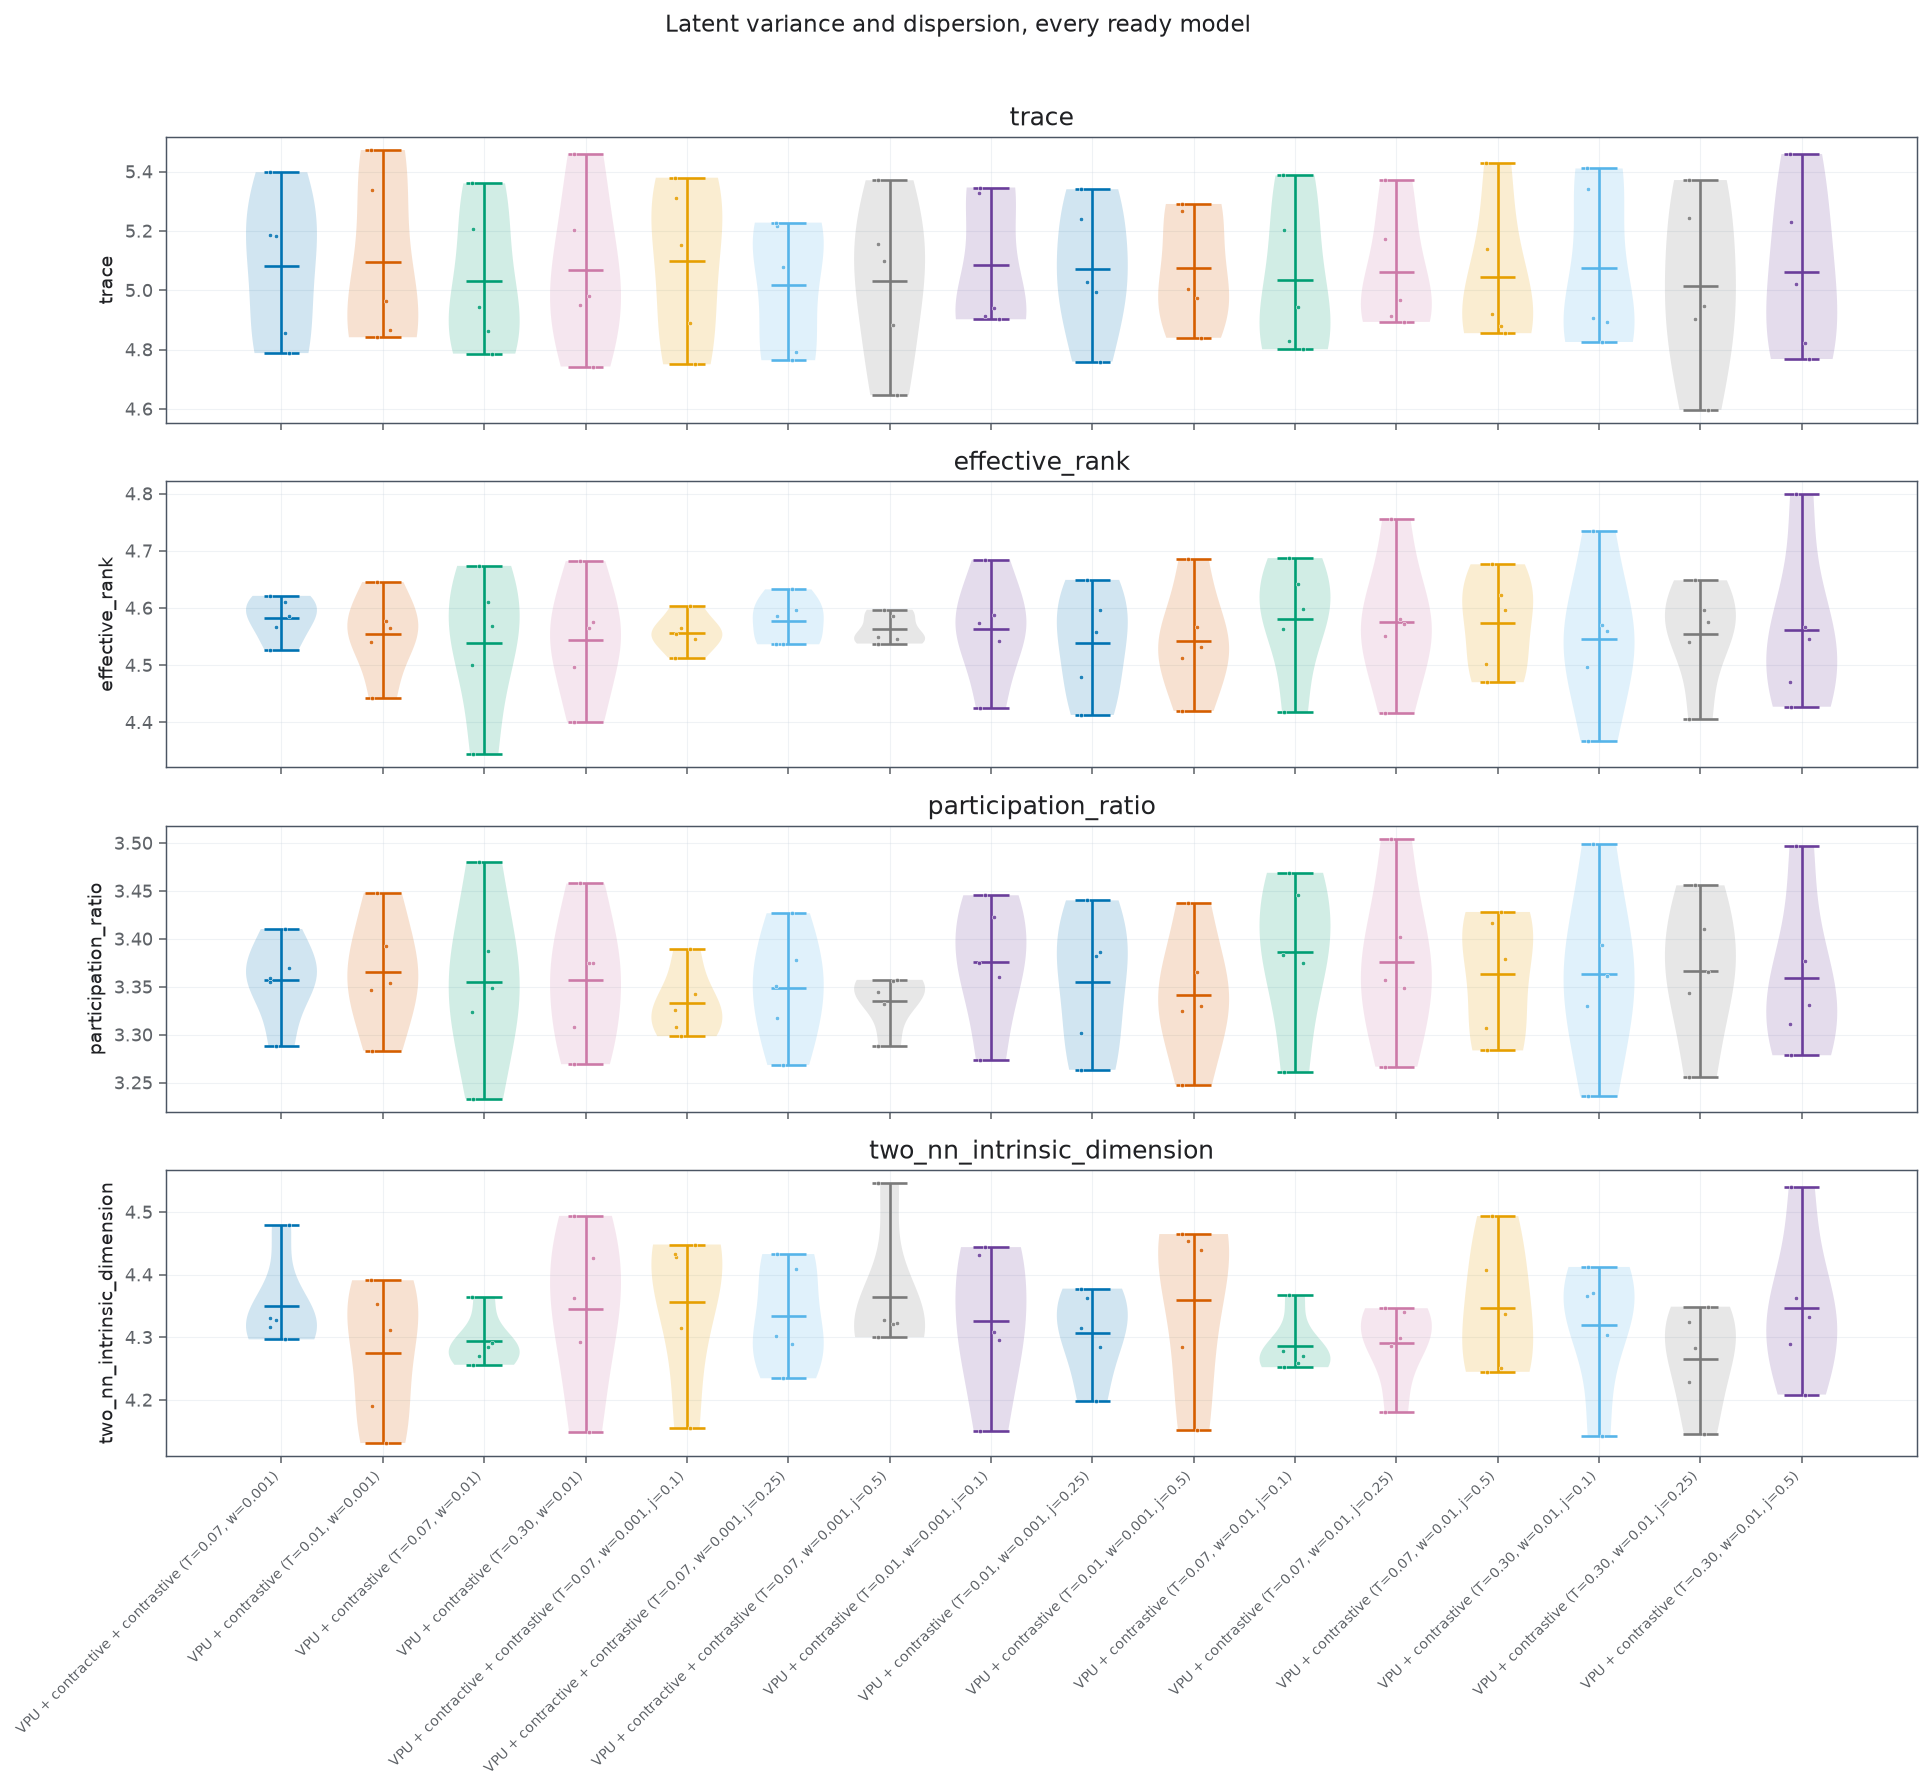

In [4]:
GEOMETRY_METRICS = ["trace", "effective_rank", "participation_ratio", "two_nn_intrinsic_dimension"]

# The base `geometry` table already carries `label`/`condition`/`repetition` (assigned
# once per model by the full-campaign precompute pass) — no re-merge with `identity`.
geometry_u = geometry_frame.query("space == 'u' and split == @EVALUATION_SPLIT")

figure, axes = plt.subplots(len(GEOMETRY_METRICS), 1, figsize=(14.0, 3.2 * len(GEOMETRY_METRICS)), dpi=theme.figure_dpi, sharex=True)

for axis, metric in zip(np.atleast_1d(axes), GEOMETRY_METRICS):
    values_by_label = geometry_u.query("metric == @metric")
    for position, label in enumerate(CONDITION_ORDER):
        values = values_by_label.query("label == @label")["value"].dropna().to_numpy()
        if not len(values):
            continue
        plot_violin_with_points(values, position=position, ax=axis, width=0.7, color=LABEL_COLOR[label], point_size=5.0, jitter=0.12, theme=theme)
    axis.set_xticks(range(len(CONDITION_ORDER)))
    axis.set(title=metric, ylabel=metric)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)

for axis in np.atleast_1d(axes)[:-1]:
    axis.tick_params(axis="x", labelbottom=False)

np.atleast_1d(axes)[-1].set_xticklabels(CONDITION_ORDER, rotation=45, ha="right", fontsize=7)

figure.suptitle("Latent variance and dispersion, every ready model", y=0.995, fontsize=12)
figure.tight_layout(rect=(0, 0, 1, 0.98))

## Angular structure of the code cloud

### Methodology

#### Theoretical

`structure_test` compares the observed pairwise cosine similarity on the canonicalized
sphere against the null a uniform code cloud would produce. A mean near the uniform
baseline's own spread indicates no strong angular clustering; a systematic shift
indicates the encoder concentrates codes in a preferred direction.

#### Implementation

Row-level cosine samples come from `latent_geometry`'s own pass (the base cache keeps
only the reduced summary); one pair count's worth of samples per model, as configured
by `pair_count`.

#### Figure descriptions

One violin per condition of the pooled cosine-similarity samples across its ready
repetitions, with a reference line at zero (the uniform-sphere expectation for the mean
cosine between two random directions in high dimension).

### Remarks

### Notes

/home/max/repositories/MSIAutoEncoderWrapper/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


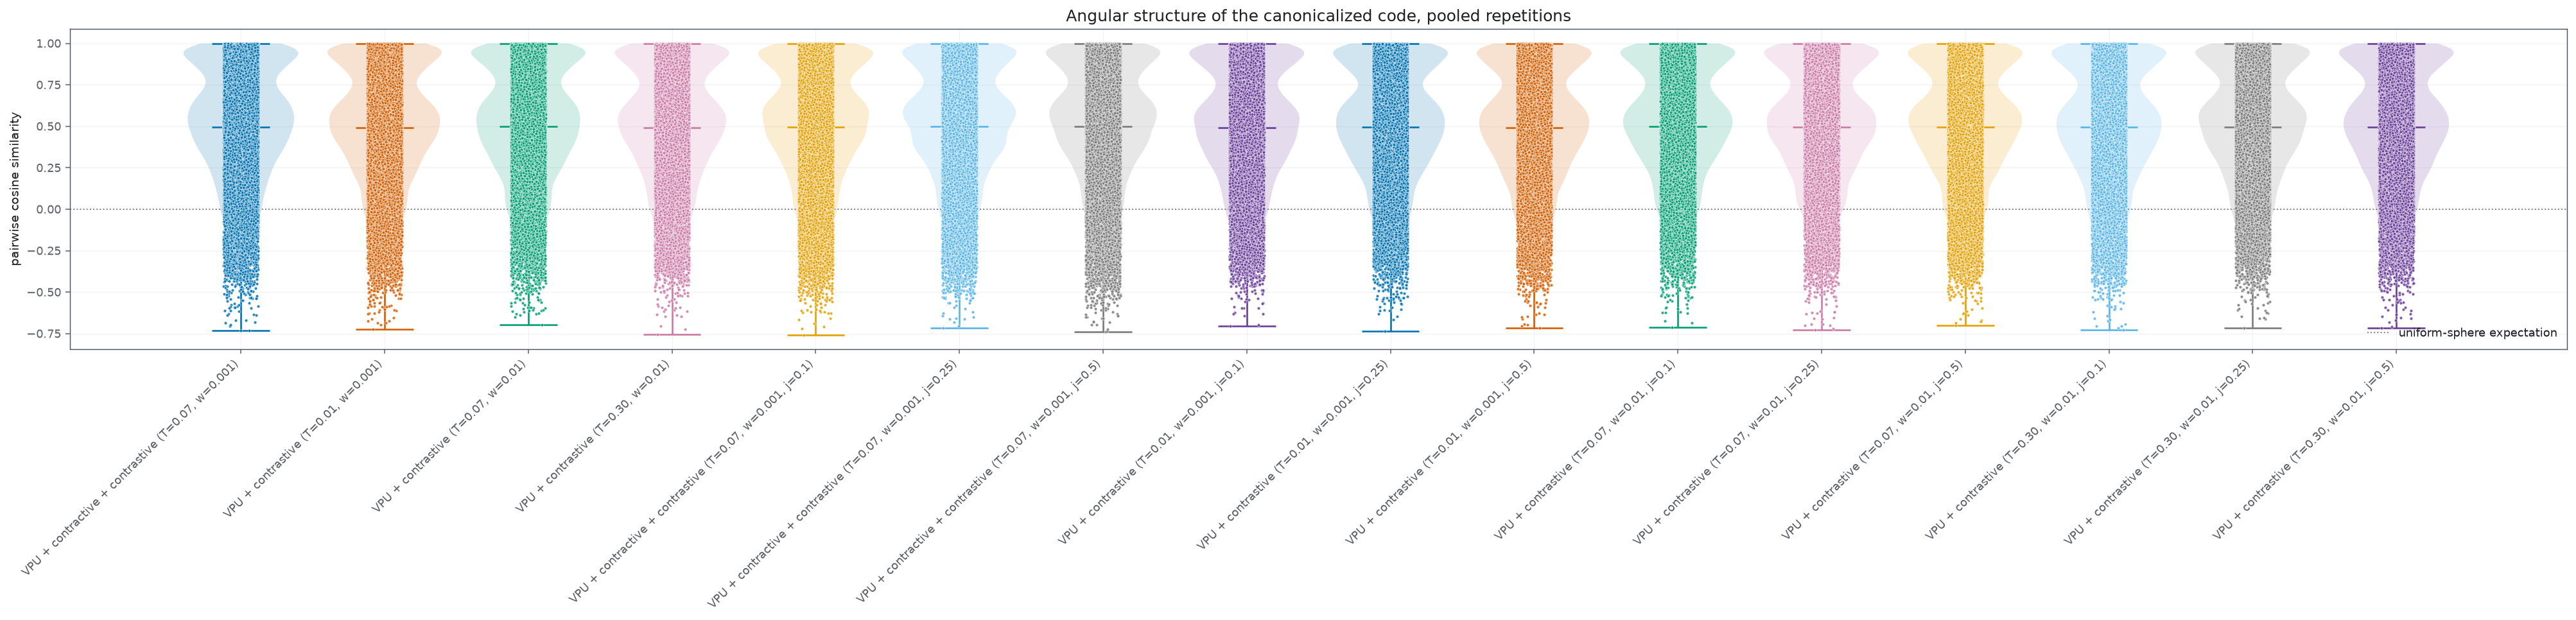

,observed_mean_cos_theta,observed_sd_cos_theta,uniform_baseline_sd_cos_theta
label,,,
"VPU + contractive + contrastive (T=0.07, w=0.001)",0.4936,0.3490,0.3333
"VPU + contrastive (T=0.01, w=0.001)",0.4908,0.3466,0.3333
"VPU + contrastive (T=0.07, w=0.01)",0.4974,0.3430,0.3333
"VPU + contrastive (T=0.30, w=0.01)",0.4914,0.3453,0.3333
"VPU + contractive + contrastive (T=0.07, w=0.001, j=0.1)",0.4934,0.3500,0.3333
"VPU + contractive + contrastive (T=0.07, w=0.001, j=0.25)",0.5004,0.3453,0.3333
"VPU + contractive + contrastive (T=0.07, w=0.001, j=0.5)",0.4988,0.3528,0.3333
"VPU + contrastive (T=0.01, w=0.001, j=0.1)",0.4917,0.3434,0.3333
"VPU + contrastive (T=0.01, w=0.001, j=0.25)",0.4961,0.3385,0.3333


In [5]:
# `cos_frame`/`structure_frame` already carry `label` (assigned inside the
# `latent_geometry` precompute routine) — no re-merge with `identity`.

figure, axis = plt.subplots(figsize=(1.5 * len(CONDITION_ORDER) + 5.0, 7.0), dpi=theme.figure_dpi)

for position, label in enumerate(CONDITION_ORDER):
    values = cos_frame.query("label == @label")["cos_theta"].dropna().to_numpy()
    if not len(values):
        continue
    plot_violin_with_points(values, position=position, ax=axis, width=0.8, color=LABEL_COLOR[label], point_size=6.0, jitter=0.12, theme=theme)

axis.axhline(0.0, color="grey", linestyle=":", linewidth=1, label="uniform-sphere expectation")
axis.set_xticks(range(len(CONDITION_ORDER)))
axis.set_xticklabels(CONDITION_ORDER, rotation=45, ha="right", fontsize=9)
axis.set(ylabel="pairwise cosine similarity", title="Angular structure of the canonicalized code, pooled repetitions")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
axis.legend(fontsize=9, frameon=theme.legend_frame)

figure.tight_layout()
plt.show()

display(
    structure_frame.groupby("label")[["observed_mean_cos_theta", "observed_sd_cos_theta", "uniform_baseline_sd_cos_theta"]]
    .mean().loc[CONDITION_ORDER].round(4)
)

## Reproducibility of the representation across seeds

### Methodology

#### Theoretical

A representation that changes shape with nothing but the initialization or data-loader
seed is not a property of the objective being evaluated; it is noise. Comparability
across seeds is a precondition for reading any other geometry statistic as a property
of the condition rather than of one lucky (or unlucky) run.

#### Implementation

`geometry_similarity` pairs every two models sharing a data contract on
`linear_cka` (both `z` and `u`), `procrustes_distance`, `knn_overlap`, `trustworthiness`
and `continuity` (u only), using each model's own cached, identically ordered sampled
rows — no new inference. This section keeps only `same_condition & ~same_seed` pairs:
different repetitions of the same swept condition.

#### Figure descriptions

One panel per stability statistic, x-axis the condition label, y-axis the pairwise
value as a violin over that condition's same-condition/different-seed pairs.

### Remarks

### Notes

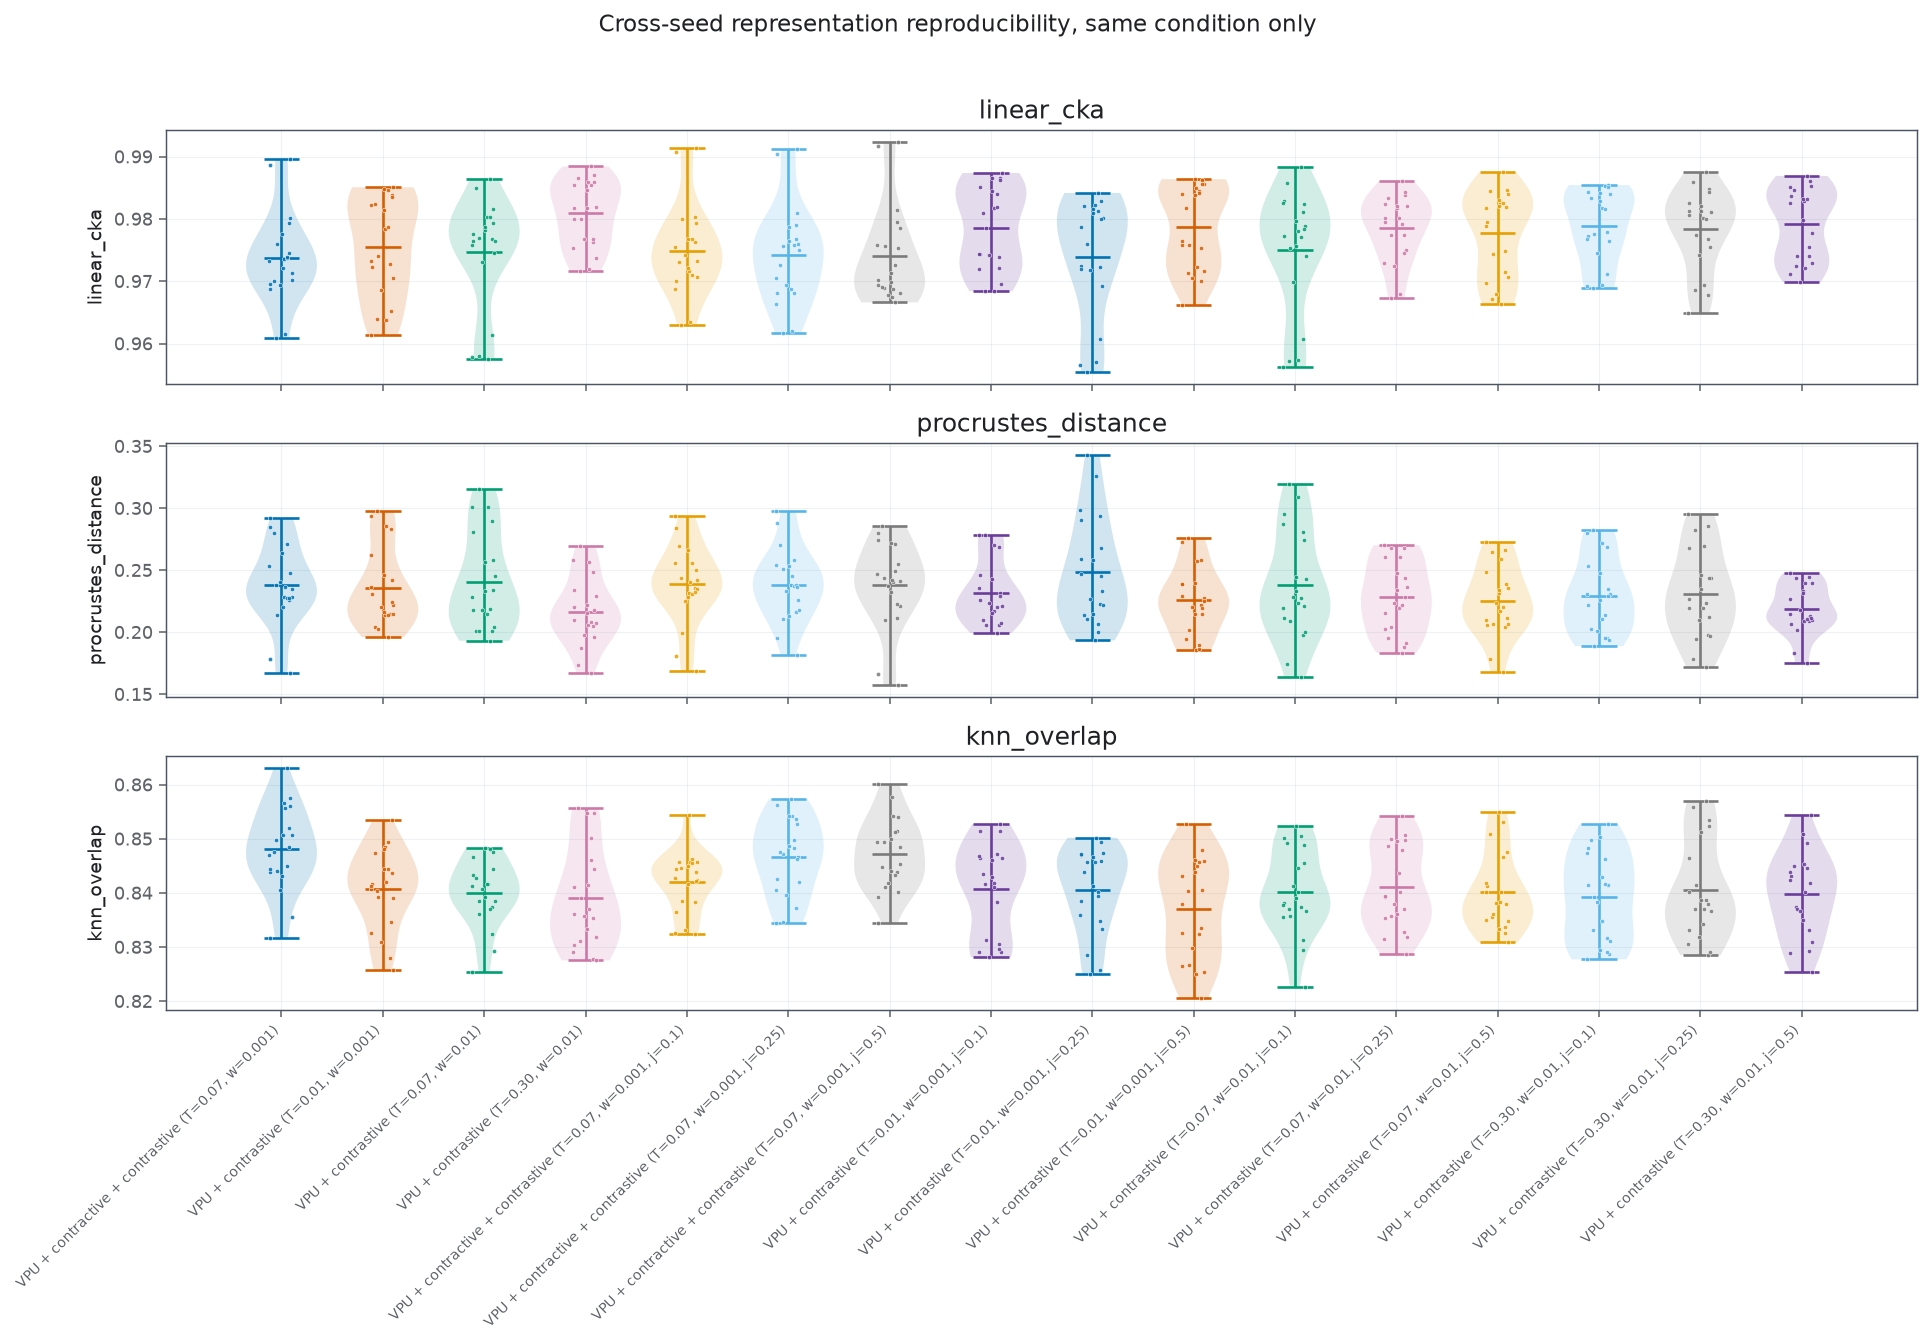

In [6]:
STABILITY_METRICS = ["linear_cka", "procrustes_distance", "knn_overlap"]

reproducibility = similarity_frame.query("same_condition and not same_seed and space == 'u'")
reproducibility = reproducibility.rename(columns={"left": "label"})

figure, axes = plt.subplots(len(STABILITY_METRICS), 1, figsize=(14.0, 3.2 * len(STABILITY_METRICS)), dpi=theme.figure_dpi, sharex=True)

for axis, metric in zip(np.atleast_1d(axes), STABILITY_METRICS):
    values_by_label = reproducibility.query("metric == @metric")
    plotted = 0
    for position, label in enumerate(CONDITION_ORDER):
        values = values_by_label.query("label == @label")["value"].dropna().to_numpy()
        if not len(values):
            continue
        plot_violin_with_points(values, position=position, ax=axis, width=0.7, color=LABEL_COLOR[label], point_size=5.0, jitter=0.12, theme=theme)
        plotted += 1
    axis.set_xticks(range(len(CONDITION_ORDER)))
    axis.set(title=metric, ylabel=metric)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
    if not plotted:
        axis.text(0.5, 0.5, "no same-condition,\ndifferent-seed pairs yet", ha="center", va="center", transform=axis.transAxes, fontsize=9, color="grey")

for axis in np.atleast_1d(axes)[:-1]:
    axis.tick_params(axis="x", labelbottom=False)

np.atleast_1d(axes)[-1].set_xticklabels(CONDITION_ORDER, rotation=45, ha="right", fontsize=7)

figure.suptitle("Cross-seed representation reproducibility, same condition only", y=0.995, fontsize=12)
figure.tight_layout(rect=(0, 0, 1, 0.98))

## Encoder sensitivity to input perturbation

### Methodology

#### Theoretical

An isotropic perturbation of growing size $\epsilon$ is a controlled probe of encoder
stability, independent of any specific spectral perturbation family: it measures how
much the canonicalized code rotates for a fixed-size, direction-agnostic nudge to the
input.

#### Implementation

`angular_sensitivity_curve` perturbs the shared evaluation sample at each configured
$\epsilon$ and measures the mean angular displacement of the canonicalized code; one
curve per ready model.

#### Figure descriptions

Left: mean angular displacement (degrees) against $\epsilon$, log-log, one line per
condition (mean over its ready repetitions). Right: violin of angular displacement at
the largest configured $\epsilon$, one violin per condition, over its ready
repetitions.

### Remarks

### Notes

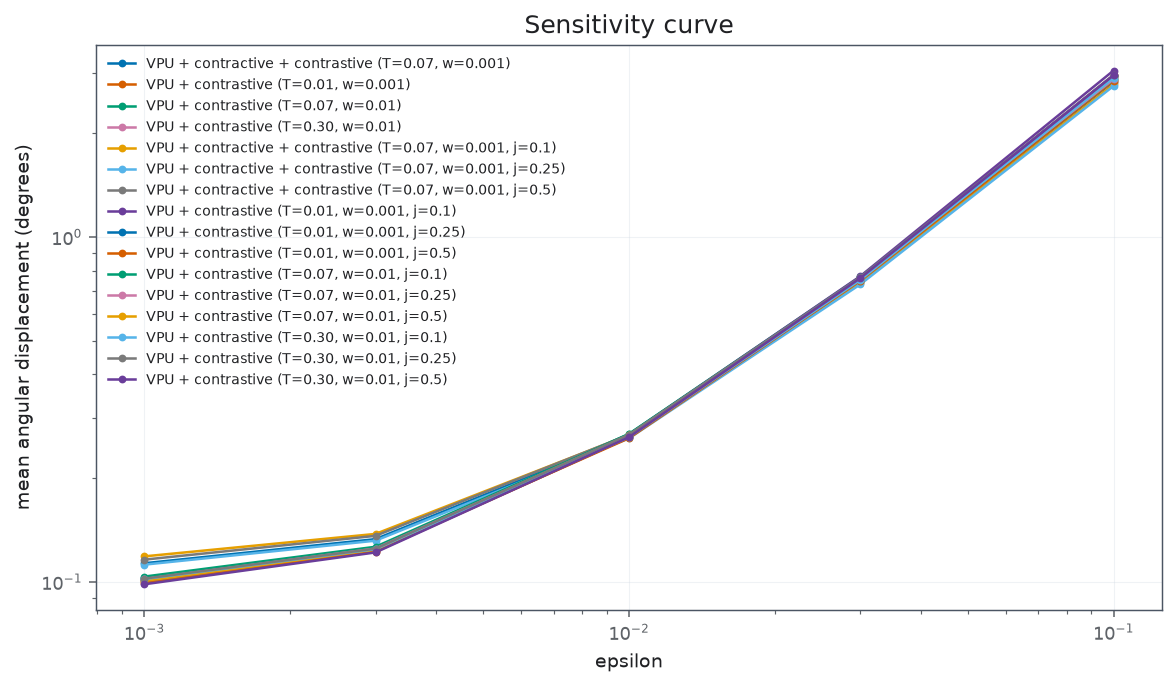

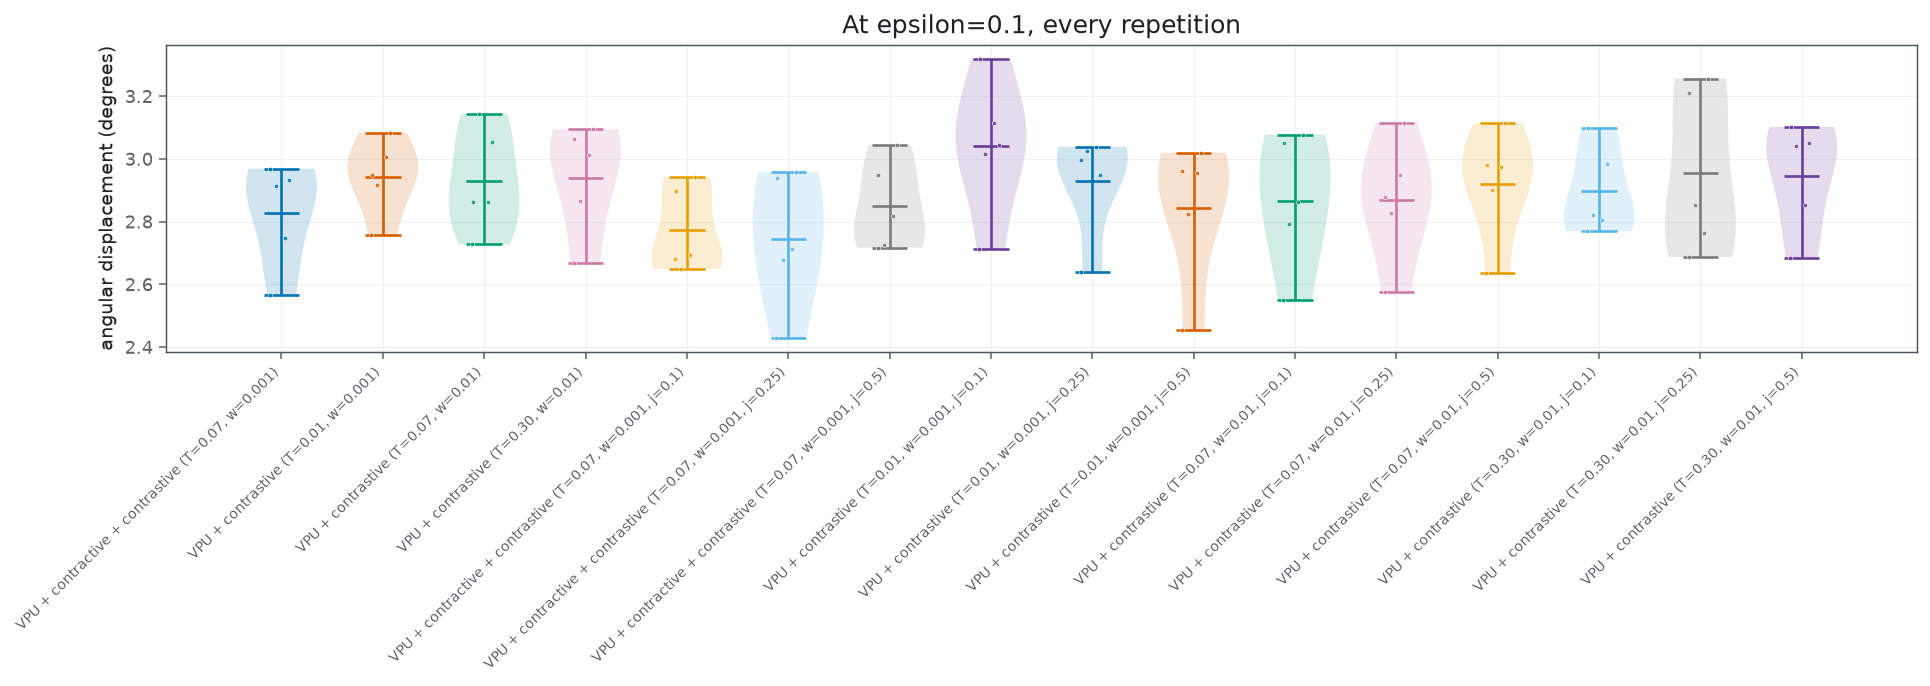

In [7]:
# `sensitivity_frame` already carries `label` (assigned inside the `latent_geometry`
# precompute routine) — no re-merge with `identity`.

largest_epsilon = sensitivity_frame.epsilon.max()

figure, curve_axis = plt.subplots(figsize=(8.5, 5.0), dpi=theme.figure_dpi)

for label in CONDITION_ORDER:
    family = sensitivity_frame.query("label == @label").groupby("epsilon")["mean_angle_degrees"].mean().reset_index()
    curve_axis.plot(family["epsilon"], family["mean_angle_degrees"], color=LABEL_COLOR[label], marker="o", markersize=3, linewidth=1.3, label=label)

curve_axis.set_xscale("log")
curve_axis.set_yscale("log")
curve_axis.set(xlabel="epsilon", ylabel="mean angular displacement (degrees)", title="Sensitivity curve")
curve_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
curve_axis.legend(fontsize=7, frameon=theme.legend_frame)
figure.tight_layout()

figure, violin_axis = plt.subplots(figsize=(14.0, 5.0), dpi=theme.figure_dpi)

for position, label in enumerate(CONDITION_ORDER):
    values = sensitivity_frame.query("label == @label and epsilon == @largest_epsilon")["mean_angle_degrees"].to_numpy()
    if not len(values):
        continue
    plot_violin_with_points(values, position=position, ax=violin_axis, width=0.7, color=LABEL_COLOR[label], point_size=5.0, jitter=0.12, theme=theme)

violin_axis.set_xticks(range(len(CONDITION_ORDER)))
violin_axis.set_xticklabels(CONDITION_ORDER, rotation=45, ha="right", fontsize=7)
violin_axis.set(ylabel="angular displacement (degrees)", title=f"At epsilon={largest_epsilon:g}, every repetition")
violin_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.tight_layout()

## Agreement between latent similarity and label similarity

### Methodology

#### Theoretical

Representational similarity analysis asks whether pairs of pixels close in the latent
code also tend to share more annotated molecules — a check that the geometry the other
sections describe is actually organized around the labels of interest, not just
internally consistent.

#### Implementation

`label_correlation_spearman_r` comes from the base cache's `geometry` table
(`label_structure_correlation`, computed once per model, canonicalized space only).

#### Figure descriptions

One violin per condition of the Spearman correlation between latent and label
similarity, over its ready repetitions, with a reference line at zero (no association).

### Remarks

### Notes

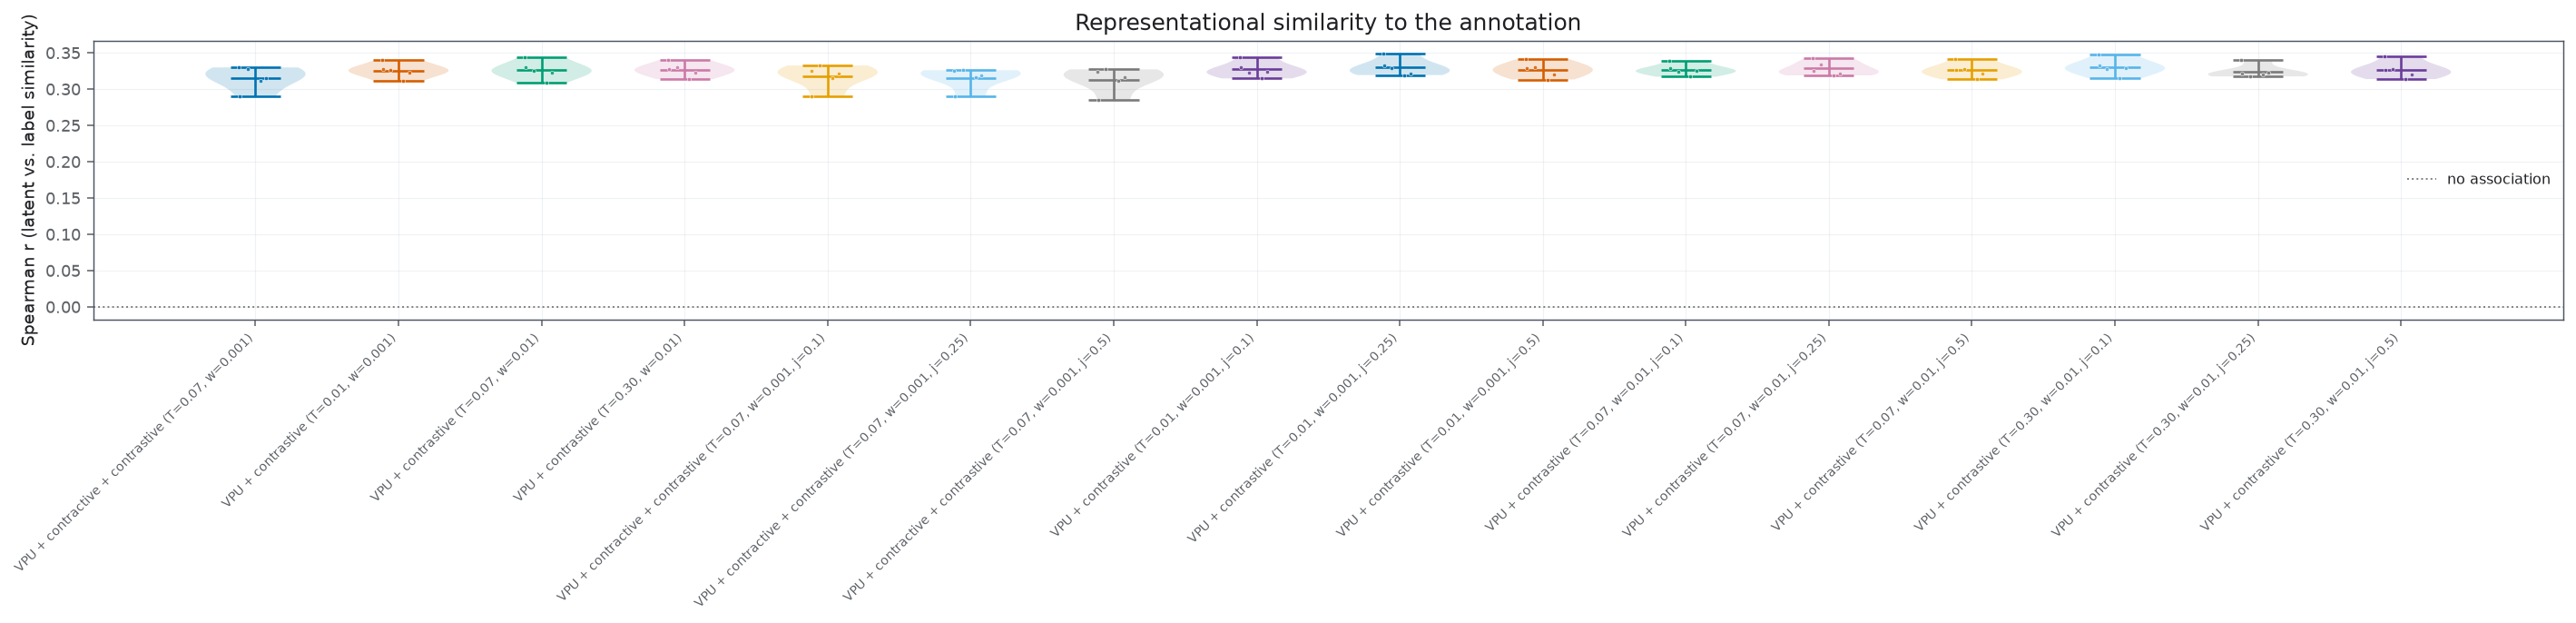

In [8]:
rsa = geometry_u.query("metric == 'label_correlation_spearman_r'")

figure, axis = plt.subplots(figsize=(1.1 * len(CONDITION_ORDER) + 3.0, 5.0), dpi=theme.figure_dpi)
for position, label in enumerate(CONDITION_ORDER):
    values = rsa.query("label == @label")["value"].dropna().to_numpy()
    if not len(values):
        continue
    plot_violin_with_points(values, position=position, ax=axis, width=0.7, color=LABEL_COLOR[label],
                            point_size=5.0, jitter=0.12, theme=theme)
axis.axhline(0.0, color="grey", linestyle=":", linewidth=1, label="no association")
axis.set_xticks(range(len(CONDITION_ORDER)))
axis.set_xticklabels(CONDITION_ORDER, rotation=45, ha="right", fontsize=7)
axis.set(ylabel="Spearman r (latent vs. label similarity)", title="Representational similarity to the annotation")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
axis.legend(fontsize=8, frameon=theme.legend_frame)
figure.tight_layout()

## Contrast against the baseline

### Methodology

#### Theoretical

The panels above show every condition's own distribution; this section adds the
paired, seed-matched contrast against `vpu_precision_sweep` for the statistics
`decision_summary` (once built) will need — most importantly trace retention, since a
representation that lost most of its variance should not be credited with
"robustness" for having less left to move.

#### Implementation

`experimental_units`/`paired_comparisons`/`baseline_contrasts` (already used by
`part_4`/`part_5`) applied to the base `geometry` table (`space == 'u'`, evaluation
split) for `trace`, `effective_rank`, `two_nn_intrinsic_dimension` and
`label_correlation_spearman_r`. Written to this notebook's own results directory, like
`part_1`/`part_2`'s own derived tables — a notebook-side aggregation, not a precompute
output.

#### Figure descriptions

Table: one row per (condition, metric), the mean paired difference against the
baseline and its across-seed interval. An interval excluding zero is a condition
distinguished from the baseline on that statistic.

### Remarks

### Notes

In [9]:
CONTRAST_METRICS = ["trace", "effective_rank", "two_nn_intrinsic_dimension", "label_correlation_spearman_r"]
contrast_source = geometry_frame.query("space == 'u' and split == @EVALUATION_SPLIT and metric in @CONTRAST_METRICS")
units = reports.experimental_units(contrast_source, ready, ["metric"])
_, contrasts = reports.paired_comparisons(units, ["metric"])
geometry_baseline_contrasts = reports.baseline_contrasts(contrasts, ready)
display(geometry_baseline_contrasts[["label", "metric", "pairs", "mean_difference", "ci_low", "ci_high"]].round(4))
reports.save_tables(ARTIFACT_DIR, geometry_baseline_contrasts=geometry_baseline_contrasts)

2026-09-19 23:44:12,820 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:203 | Oriented 48 baseline contrasts as candidate minus reference.


,label,metric,pairs,mean_difference,ci_low,ci_high
0,"VPU + contractive + contrastive (T=0.07, w=0.0...",NaN,0,NaN,NaN,NaN
1,"VPU + contrastive (T=0.30, w=0.01, j=0.25)",NaN,0,NaN,NaN,NaN
2,"VPU + contrastive (T=0.30, w=0.01, j=0.1)",NaN,0,NaN,NaN,NaN
3,"VPU + contrastive (T=0.07, w=0.01, j=0.25)",NaN,0,NaN,NaN,NaN
4,"VPU + contrastive (T=0.01, w=0.001, j=0.5)",NaN,0,NaN,NaN,NaN
5,"VPU + contrastive (T=0.01, w=0.001, j=0.1)",NaN,0,NaN,NaN,NaN
6,"VPU + contrastive (T=0.01, w=0.001, j=0.25)",NaN,0,NaN,NaN,NaN
7,"VPU + contractive + contrastive (T=0.07, w=0.0...",NaN,0,NaN,NaN,NaN
8,"VPU + contrastive (T=0.07, w=0.01, j=0.5)",NaN,0,NaN,NaN,NaN
9,"VPU + contractive + contrastive (T=0.07, w=0.0...",NaN,0,NaN,NaN,NaN


2026-09-19 23:44:12,832 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:345 | Saved 1 analytical tables in assets/experiments/autoencoder_architecture/notebooks/segmentation_model/19_09_26_metaspace_heads_vpu_jaccard/part_3_latent_geometry_results.


## Reproducible artifacts

### Methodology

#### Implementation

The measured tables and their provenance are written by the precompute runner, not
here; this notebook additionally writes `geometry_baseline_contrasts.csv`, a cheap
derived aggregation of tables already in memory. Provenance, including the commit, the
device, the seeds and the source hashes of the analysis modules, lives in the runner's
`metadata.json`.

The results directory is deliberately not versioned: it is regenerable.

### Remarks

### Notes

In [10]:
print("artifacts present:", sorted(path.name for path in ARTIFACT_DIR.glob("*.csv")))
print("provenance:", {"analysis": provenance["analysis"], "git_commit": provenance["git_commit"],
                      "device": provenance["settings"]["device"], "evaluation_split": EVALUATION_SPLIT,
                      "pair_count": provenance["pair_count"], "models": provenance["models"]})

artifacts present: ['angular_sensitivity.csv', 'angular_structure.csv', 'angular_structure_samples.csv', 'geometry_baseline_contrasts.csv']
provenance: {'analysis': 'latent_geometry', 'git_commit': 'b2026c4bcdb93b4bb5ceb647ae2bbdfb06d0feef', 'device': 'cuda', 'evaluation_split': 'test', 'pair_count': 5000, 'models': 80}


## Results / Summary

### LLM

Not yet run against the real campaign cache. This notebook has not been executed
against `data/kidney_workspace`; run the base inference cache and then this analysis's
precompute command printed above, then write this section from the actually observed
geometry statistics, reproducibility and baseline contrasts before treating any
interpretation here as verified.

### Person